# Wavelet Source Detection for 3-D Spectral Cubes

Per-slice starlet (à trous IUWT) detection above diffuse emission.

**Strategy:**  
The starlet transform decomposes each spectral slice into fine detail bands (compact sources) and a coarse residual (diffuse emission). By thresholding only the fine scales we detect compact sources *above* the diffuse halo. Sources are found globally on the max-projected significance map, then measured per channel within Voronoi territories.

**Pipeline:**  
1. Per-channel significance maps (fine starlet scales, MAD noise, optional diffuse subtraction)  
2. Max-project → global significance  
3. `peak_local_max` → N source peaks  
4. Voronoi assignment → N territories  
5. Per-channel footprint = connected component at peak pixel within territory

## Imports

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path
from typing import NamedTuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass, label as nd_label
from skimage.measure import regionprops

## Multi-format cube loader

In [2]:
def load_cube(path: str | Path) -> np.ndarray:
    """Load a spectral cube from HDF5, FITS, .npy, or .npz.

    Always returns float32 (n_ch, H, W).
    """
    path = Path(path)
    suf = path.suffix.lower()

    if suf in (".h5", ".hdf5"):
        import h5py
        with h5py.File(path, "r") as f:
            cube = f["cube"][:].astype(np.float32)

    elif suf in (".fits", ".fit"):
        from astropy.io import fits
        with fits.open(path) as hdul:
            data = hdul[0].data
        if data is None:
            raise ValueError(f"No data in primary HDU of {path}")
        data = np.squeeze(data).astype(np.float32)
        if data.ndim == 2:
            data = data[np.newaxis]
        if data.ndim != 3:
            raise ValueError(f"Cannot interpret FITS array with shape {data.shape} as (n_ch,H,W)")
        cube = data

    elif suf == ".npy":
        cube = np.load(path).astype(np.float32)
        if cube.ndim == 2:
            cube = cube[np.newaxis]

    elif suf == ".npz":
        arch = np.load(path)
        if "cube" in arch:
            cube = arch["cube"].astype(np.float32)
        else:
            key = list(arch.keys())[0]
            cube = arch[key].astype(np.float32)

    else:
        raise ValueError(f"Unsupported file extension: {suf!r}. "
                         "Use .h5/.hdf5, .fits/.fit, .npy, or .npz")

    if cube.ndim != 3:
        raise ValueError(f"Loaded array has shape {cube.shape}; expected (n_ch, H, W)")

    np.nan_to_num(cube, copy=False, nan=0.0)
    return cube


def active_channels(cube: np.ndarray, threshold_frac: float = 0.05) -> list[int]:
    """Return indices of channels whose positive flux exceeds `threshold_frac` of the max.

    Uses only positive flux (clipped at zero) so noise-dominated channels don't inflate the total.
    """
    flux = np.nansum(np.clip(cube, 0.0, None), axis=(1, 2))
    thresh = threshold_frac * float(flux.max())
    return [int(i) for i in np.where(flux >= thresh)[0]]

## W2246-0526: Cube Loader (raw or IST-denoised)

Set `USE_DENOISED = True` to use the IST-denoised cube; `False` for the raw noisy FITS cube.

| `USE_DENOISED` | cube | denoising threshold |
|---|---|---|
| `False` | raw FITS | — |
| `True` | IST `.npy` | 5σ spatial+spectral (finest scale 7σ) |

`active_channels` with `threshold_frac=0.3` selects only emission-bright channels.
`W2246_THRESH` sets a global absolute floor on the wavelet detection plane.

In [3]:
USE_DENOISED = True   # True = IST-denoised FITS  |  False = raw FITS

_RAW_FITS      = 'data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314.fits'
_DENOISED_FITS = '/Users/arnablahiry/repos/IFU-Source-ID/data/observed_cubes/CROPPED_ONLY_SPATIAL_W2246_CII_314_denoised_ist.fits'

# Both files carry a full WCS header — load cube and header from the same file.
_CUBE_PATH = _DENOISED_FITS if USE_DENOISED else _RAW_FITS
_label     = 'IST-denoised' if USE_DENOISED else 'raw noisy'

from astropy.io import fits as _afits
from astropy.wcs import WCS as _WCS
from astropy.cosmology import Planck18 as _Planck18
import astropy.units as _u

with _afits.open(_CUBE_PATH) as _hdul:
    _hdr = _hdul[0].header.copy()
    cube = np.ascontiguousarray(np.squeeze(_hdul[0].data), dtype=np.float32)

np.nan_to_num(cube, copy=False, nan=0.0)
np.clip(cube, 0.0, None, out=cube)   # negative flux is non-physical; clip to zero

n_ch, H, W = cube.shape
n_spectral_channels = n_ch
_RESULTS_DIR = f"../results/w2246_{n_spectral_channels}"
print(f'W2246 {_label} cube : {cube.shape}')
print(f'Flux range          : [{cube.min():.3e}, {cube.max():.3e}]')
print(f'Noise std (global)  : {cube.std():.3e}')

channel_list = active_channels(cube, threshold_frac=0.16)
channel_list = list(range(max(0, channel_list[0] - 10),
                         min(n_ch, channel_list[-1] + 6)))
print(f'Active channels     : {len(channel_list)}'
      f'  (ch {channel_list[0]}–{channel_list[-1]})')

thresh_frac  = 0.015
W2246_THRESH = thresh_frac * float(cube.max())
print(f'Detection floor     : {W2246_THRESH:.3e}  ({thresh_frac} × cube.max())')

# ── Spectral WCS → velocity array ─────────────────────────────────────────
_crval3  = float(_hdr['CRVAL3'])    # Hz, reference frequency
_cdelt3  = float(_hdr['CDELT3'])    # Hz / channel
_crpix3  = float(_hdr['CRPIX3'])    # 1-based reference pixel
_restfrq = float(_hdr['RESTFRQ'])   # Hz, line rest frequency
_C_KMS   = 299792.458                  # km/s

_freq_arr = _crval3 + _cdelt3 * (np.arange(n_ch) - (_crpix3 - 1))
vel_array = _C_KMS * (_restfrq - _freq_arr) / _restfrq   # km/s, shape (n_ch,)
print(f'Velocity range : [{vel_array.min():.1f}, {vel_array.max():.1f}] km/s')
print(f'  channel 0   : {vel_array[0]:.1f} km/s')
print(f'  channel {n_ch-1:<3d} : {vel_array[n_ch-1]:.1f} km/s')

# ── 2-D celestial WCS (pixel → RA/Dec) ────────────────────────────────────
_wcs2d = _WCS(_hdr).celestial

# ── Pixel scale in kpc ────────────────────────────────────────────────────
_z            = 4.6
_pixscale_deg = abs(float(_hdr['CDELT1']))
_pixscale_as  = _pixscale_deg * 3600
_kpc_per_as   = _Planck18.kpc_proper_per_arcmin(_z).to('kpc/arcsec').value
pixscale_kpc  = _pixscale_as * _kpc_per_as
print(f'Pixel scale    : {pixscale_kpc:.3f} kpc/px')


W2246 IST-denoised cube : (314, 200, 200)
Flux range          : [0.000e+00, 9.196e-03]
Noise std (global)  : 1.646e-04
Active channels     : 158  (ch 88–245)
Detection floor     : 1.379e-04  (0.015 × cube.max())
Velocity range : [-1557.0, 1573.0] km/s
  channel 0   : -1557.0 km/s
  channel 313 : 1573.0 km/s
Pixel scale    : 0.334 kpc/px


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


[run_flow_tracker]  cube=(314, 200, 200)  channels=158  (ch 88–245)
  wavelet: scales=6  k_sigma=5.0  use_scale=4  min_area=10  thresh=0.0001379351411014795  mean_map_sigma=True
  tracker: min_match_overlap=5  min_split_overlap=3  max_gap_dist=15.0  max_gap_channels=5  min_displacement=3.0

[Stage 0] Per-channel wavelet detection...
  → 158 channels processed  |  157 with detections  |  292 total blobs

[Stage 1] Computing masked TV-L1 optical flow for 157 channel pairs...
  → 157 flow pairs computed.

[Stage 2] Linking tracks across 158 channels (157 transitions)...
  Seeded 1 track(s) from channel 88 (1 blob(s))
  → 8 total tracks created.

[Stage 3] Kinematic classification  (min_displacement=3.0 px)
  track  0  kinematic  ch 88–235  disp=24.4 px
  track  1  kinematic  ch 127–178  disp=13.2 px
  track  2  kinematic  ch 141–176  disp=25.5 px
  track  3  kinematic  ch 179–245  disp=88.2 px
  track  4  kinematic  ch 191–192  merge_into=[3]
  track  5  static     ch 215–220  displacemen

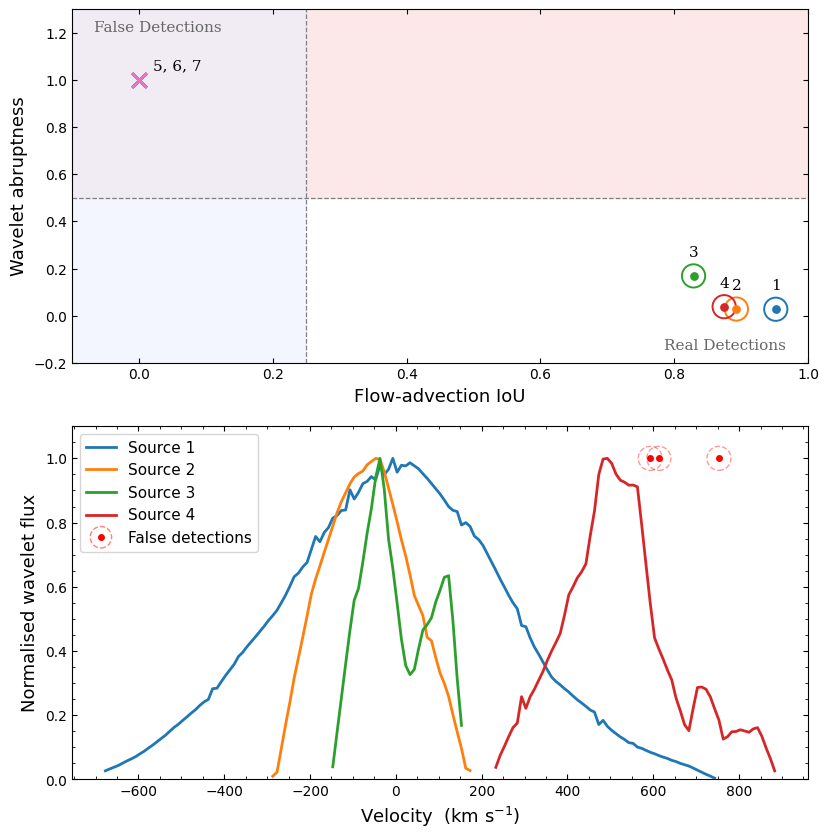

In [4]:
import sys
import matplotlib
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import matplotlib.cm as cm

_scripts_wavelet = Path('../scripts')
if str(_scripts_wavelet) not in sys.path:
    sys.path.insert(0, str(_scripts_wavelet))

from flow_tracker import run_flow_tracker

_thresh = globals().get('W2246_THRESH', None)

(
    detections, flow_seq, tracks, sources,
    good_sources, false_dets, src_data, src_colors,
) = run_flow_tracker(
    cube,
    channel_list=channel_list,
    scales=6, k_sigma=5.0, use_scale=4, min_area=10,
    thresh=_thresh,
    use_mean_map_sigma=True,
    min_match_overlap=5, min_split_overlap=3, max_gap_dist=15.0, max_gap_channels=5,
    min_displacement=3.0,
    wav_abrupt_thresh=0.5, flow_iou_thresh=0.25,
    verbose=True, plot=True,
    vel_array=vel_array,
    results_dir=_RESULTS_DIR,
)

frames    = [(d.channel, d.image, d.footprint_masks, d.peaks, d.boxes) for d in detections]
flow_data = list(flow_seq)

mask_to_source: dict[int, int] = {}
for t in tracks:
    for ch, mask in t['masks'].items():
        mask_to_source[id(mask)] = t['source_id']

plt.rcParams.update(plt.rcParamsDefault)


In [5]:
def _footprint_overlay(footprint_masks, H, W, alpha=1):
    union = np.zeros((H, W), dtype=bool)
    for m in footprint_masks:
        union |= m
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[~union] = [0, 0, 0, alpha]
    return rgba

In [6]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ── Detection + flow GIF  (good sources only) ────────────────────────────
import matplotlib.patches as mpatches

_good_ids   = {s['id'] for s in good_sources}
_flow_by_ch = {cr: ff for cr, ct, ff, _ in flow_data}

# chronological labels
def _first_ch_src(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999
_good_chrono  = sorted(good_sources, key=_first_ch_src)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

H, W  = frames[0][1].shape
qs    = 5
ys_q  = np.arange(0, H, qs)
xs_q  = np.arange(0, W, qs)
Xq, Yq = np.meshgrid(xs_q, ys_q)
n_pts   = Xq.size

vmin = min(f[1].min() for f in frames)
vmax = max(f[1].max() for f in frames)

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

fig = plt.figure(figsize=(8, 5))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[0.04, 1],
    hspace=0.06, wspace=0.03,
    left=0.02, right=0.98, top=0.88, bottom=0.04,
)
ax_cb  = fig.add_subplot(gs[0, :])
ax_det = fig.add_subplot(gs[1, 0])
ax_flo = fig.add_subplot(gs[1, 1])
for ax in (ax_det, ax_flo):
    ax.set_xticks([]); ax.set_yticks([])

ax_det.text(0.04, 0.96, 'Detections', transform=ax_det.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
ax_flo.text(0.04, 0.96, 'Optical Flow', transform=ax_flo.transAxes,
            va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))

_first_good = [m for m in frames[0][2]
               if mask_to_source.get(id(m), -1) in _good_ids]

im_l = ax_det.imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax, origin='lower')
im_r = ax_flo.imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax, origin='lower')
ov   = ax_det.imshow(_footprint_overlay(_first_good, H, W),
                     origin='lower', interpolation='nearest')

quiv = ax_flo.quiver(
    Xq.ravel(), Yq.ravel(), np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts),
    cmap='cool', angles='xy', scale_units='xy', scale=1,
    width=0.003, headwidth=4, headlength=5, alpha=0.9, clim=(0, 3),
)

_sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=vmin, vmax=vmax))
_cb = fig.colorbar(_sm, cax=ax_cb, orientation='horizontal')
_cb.ax.tick_params(labelsize=10, direction='out')
_cb.set_label('Jy beam$^{-1}$', fontsize=12, labelpad=8)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

_ch_text = ax_det.text(0.98, 0.03, '', transform=ax_det.transAxes,
                       va='bottom', ha='right', fontsize=12, color='white',
                       fontfamily='serif',
                       bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.45, ec='none'))

# static scalebar — optical flow panel only, 15 kpc, same style as moment maps
_sb_kpc_gif = 15.0
_sb_px_gif  = _sb_kpc_gif / pixscale_kpc
_sb_x0_gif  = W * 0.70
_sb_y0_gif  = H * 0.07
ax_flo.plot([_sb_x0_gif, _sb_x0_gif + _sb_px_gif], [_sb_y0_gif, _sb_y0_gif],
            color='white', lw=1.5, zorder=5)
ax_flo.text(_sb_x0_gif + _sb_px_gif / 2, H * 0.12, f'{_sb_kpc_gif:.1f} kpc',
            color='white', ha='center', va='bottom', fontsize=10,
            fontfamily='serif', zorder=5)

_contours, _markers, _bboxes, _blabels = [], [], [], []
_PAD_BB = 4

def _light(color):
    c = np.array(matplotlib.colors.to_rgb(color))
    return tuple(0.3 * c + 0.7)

def _draw_flow_boxes(footprint_masks, peaks):
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color  = src_colors.get(sid, (1,1,1,1))
        lcolor = _light(color)
        rows, cols = np.where(mask)
        if len(rows) == 0: continue
        r0, r1 = int(rows.min()), int(rows.max())
        c0, c1 = int(cols.min()), int(cols.max())
        clbl = str(_chrono_label.get(sid, sid + 1))
        # bbox on flow panel (full opacity)
        rect_r = mpatches.Rectangle(
            (c0 - _PAD_BB, r0 - _PAD_BB),
            c1 - c0 + 2*_PAD_BB, r1 - r0 + 2*_PAD_BB,
            linewidth=0.8, edgecolor=lcolor, facecolor='none', zorder=4
        )
        ax_flo.add_patch(rect_r)
        _bboxes.append(rect_r)
        bl_r = ax_flo.text(
            c1 + _PAD_BB, r1 + _PAD_BB, clbl,
            ha='center', va='center', fontsize=7,
            color='black', fontweight='bold', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.22', fc=lcolor, ec=lcolor, lw=1.2),
            zorder=6
        )
        _blabels.append(bl_r)
        # bbox on detection panel (low opacity rect, full opacity circle)
        rect_l = mpatches.Rectangle(
            (c0 - _PAD_BB, r0 - _PAD_BB),
            c1 - c0 + 2*_PAD_BB, r1 - r0 + 2*_PAD_BB,
            linewidth=0.8, edgecolor=lcolor, facecolor='none',
            alpha=0.35, zorder=4
        )
        ax_det.add_patch(rect_l)
        _bboxes.append(rect_l)
        bl_l = ax_det.text(
            c1 + _PAD_BB, r1 + _PAD_BB, clbl,
            ha='center', va='center', fontsize=7,
            color='black', fontweight='bold', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.22', fc=lcolor, ec=lcolor, lw=1.2),
            zorder=6
        )
        _blabels.append(bl_l)

# ── reset before animation ────────────────────────────────────────────────
for _cs in list(ax_det.collections):
    try: _cs.remove()
    except: pass
for _ln in list(ax_det.lines):
    try: _ln.remove()
    except: pass
for _bb in _bboxes:
    try: _bb.remove()
    except: pass
for _bl in _blabels:
    try: _bl.remove()
    except: pass
_bboxes.clear(); _blabels.clear()
im_l.set_data(frames[0][1]); im_r.set_data(frames[0][1])
ov.set_data(_footprint_overlay(
    [m for m in frames[0][2] if mask_to_source.get(id(m),-1) in _good_ids], H, W))
_ch_text.set_text('')

def _update(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_l.set_data(img); im_r.set_data(img)
    good_masks = [m for m in footprint_masks
                  if mask_to_source.get(id(m), -1) in _good_ids]
    ov.set_data(_footprint_overlay(good_masks, H, W))
    for cs in _contours: cs.remove()
    _contours.clear()
    for mk in _markers: mk.remove()
    _markers.clear()
    for bb in _bboxes: bb.remove()
    _bboxes.clear()
    for bl in _blabels: bl.remove()
    _blabels.clear()
    for i, mask in enumerate(footprint_masks):
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids: continue
        color = src_colors.get(sid, (1, 1, 1, 1))
        cs = ax_det.contour(mask.astype(float), [0.5], colors=[color], linewidths=0.7)
        _contours.append(cs)
        if i < len(peaks):
            yy, xx = peaks[i]
            mk, = ax_det.plot(xx, yy, marker='+', ms=7, mew=1.0,
                              color=color, linestyle='none')
            _markers.append(mk)
    _draw_flow_boxes(footprint_masks, peaks)
    if ch in _flow_by_ch:
        ff    = _flow_by_ch[ch]
        v_q   = ff[0][ys_q[:, None], xs_q[None, :]].ravel()
        u_q   = ff[1][ys_q[:, None], xs_q[None, :]].ravel()
        mag_q = np.hypot(u_q, v_q)
        pk_m  = float(mag_q.max())
        if pk_m > 1e-6:
            quiv.set_UVC(u_q * qs * 0.8 / pk_m, v_q * qs * 0.8 / pk_m, mag_q)
        else:
            quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    else:
        quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))
    _v = float(vel_array[ch])
    _ch_text.set_text(f'ch {ch}  |  $\\mathbf{{{_v:.0f}\\ km\\ s^{{-1}}}}$')
    return [im_l, im_r, ov, _ch_text]

_ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=300, blit=False)
_ani.save(f'{_RESULTS_DIR}/detections_flow.gif', writer='pillow', fps=8)
plt.close(fig)
print(f'Saved {_RESULTS_DIR}/detections_flow.gif  ({len(frames)} frames)')

plt.rcParams.update(plt.rcParamsDefault)


Saved results/w2246_314/detections_flow.gif  (158 frames)


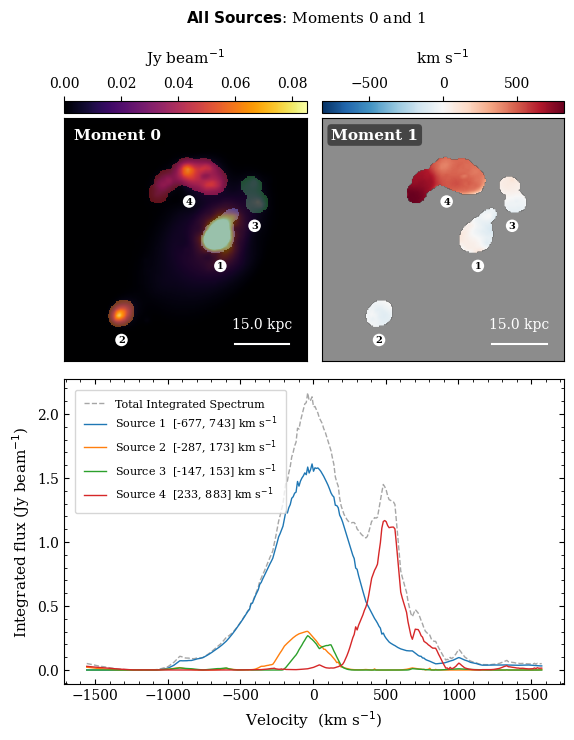

In [7]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ── Full-field Moment 0 + Moment 1 overview ──────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from astropy.cosmology import Planck18
import astropy.units as u

plt.rcParams.update({
    'font.family':    'serif',
    'font.size':       11,
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

_nH, _nW = cube.shape[1], cube.shape[2]
_good_ids = {s['id'] for s in good_sources}

# pixel scale → kpc
_z             = 4.6
_pixscale_deg  = abs(float(_hdr['CDELT1']))
_pixscale_as   = _pixscale_deg * 3600
_kpc_per_as    = Planck18.kpc_proper_per_arcmin(_z).to('kpc/arcsec').value
_pixscale_kpc  = _pixscale_as * _kpc_per_as
_scalebar_kpc  = 15
_scalebar_px   = _scalebar_kpc / _pixscale_kpc

# union footprint per good source
_src_union = {}
for src in good_sources:
    m = np.zeros((_nH, _nW), dtype=bool)
    for t in tracks:
        if t['id'] in src['track_ids']:
            for mask in t['masks'].values():
                m |= mask
    _src_union[src['id']] = m

_all_union = np.zeros((_nH, _nW), dtype=bool)
for m in _src_union.values():
    _all_union |= m

# sort sources chronologically by first detected channel
def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(good_sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}

# Moment 0
_det_chs_all = sorted({
    ch for src in good_sources for t in tracks
    if t['id'] in src['track_ids'] for ch in t['masks']
})
_det_idx   = np.array(_det_chs_all) if _det_chs_all else np.array(channel_list)
_mom0_full = cube[_det_idx].sum(axis=0)

# Moment 1
_flux_stack = cube[_det_idx]
_total_flux = _flux_stack.sum(axis=0)
with np.errstate(invalid='ignore', divide='ignore'):
    _mom1_full = np.where(
        (_total_flux > 0) & _all_union,
        (_flux_stack * vel_array[_det_idx][:, None, None]).sum(axis=0) / _total_flux,
        np.nan,
    )

# RGBA overlay
_rgba = np.zeros((_nH, _nW, 4), dtype=np.float32)
_rgba[~_all_union] = [0, 0, 0, 0.6]
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    r, g, b = matplotlib.colors.to_rgb(src_colors[src['id']])
    _rgba[m] = [r, g, b, 0.45]

# ── figure — identical layout to subfigures ───────────────────────────────
fig = plt.figure(figsize=(5.5, 7.5))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.1],
    hspace=0.01, wspace=0.06,
    left=0.06, right=0.97, top=0.86, bottom=0.08,
)
ax_m0 = fig.add_subplot(gs[0, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_sp = fig.add_subplot(gs[1, :])

# ── title ─────────────────────────────────────────────────────────────────
fig.text(0.5, 0.962, r"$\mathbf{All\ Sources}$: Moments 0 and 1",
         ha='center', fontsize=11, fontfamily='serif')

# ── Moment 0 ──────────────────────────────────────────────────────────────
_v0p, _v1p = np.nanpercentile(_mom0_full, [1, 99])
_im0 = ax_m0.imshow(_mom0_full, cmap='inferno', origin='lower', vmin=_v0p, vmax=_v1p)
ax_m0.imshow(_rgba, origin='lower', interpolation='nearest')
ax_m0.set_xticks([]); ax_m0.set_yticks([])
ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb0 = fig.colorbar(_im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
cb0.ax.tick_params(labelsize=10, direction='out')
cb0.set_label('Jy beam$^{-1}$', fontsize=11, labelpad=10)

_sb_x0  = _nW * 0.70
_sb_y0  = _nH * 0.07
_sb_txt = _nH * 0.12
ax_m0.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m0.text(_sb_x0 + _scalebar_px / 2, _sb_txt, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# ── Moment 1 ──────────────────────────────────────────────────────────────
ax_m1.set_facecolor('0.55')
_mom1_show = np.where(_all_union, _mom1_full, np.nan)
_m1_vmax   = float(np.nanmax(np.abs(_mom1_show)))
_im1 = ax_m1.imshow(_mom1_show, cmap='RdBu_r', origin='lower',
                    vmin=-_m1_vmax, vmax=_m1_vmax)
ax_m1.set_xticks([]); ax_m1.set_yticks([])
ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
           va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
           fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
cb1 = fig.colorbar(_im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
cb1.ax.tick_params(labelsize=10, direction='out')
cb1.set_label('km s$^{-1}$', fontsize=11, labelpad=10)

ax_m1.plot([_sb_x0, _sb_x0 + _scalebar_px], [_sb_y0, _sb_y0], color='white', lw=1.5)
ax_m1.text(_sb_x0 + _scalebar_px / 2, _sb_txt, f'{_scalebar_kpc:.1f} kpc',
           color='white', ha='center', va='bottom', fontsize=10, fontfamily='serif')

# ── source number circles — just outside each footprint ──────────────────
for src in _good_chrono:
    m = _src_union[src['id']]
    if not m.any(): continue
    _rows, _cols = np.where(m)
    _cy_s, _cx_s = _rows.mean(), _cols.mean()
    # place label just below the footprint bottom edge (per-label fine-tune)
    _y_nudge = {1: -8, 2: -8, 3: -8, 4: 4}
    _lx = _cx_s
    _ly = _rows.min() - 3 + _y_nudge.get(_chrono_label[src['id']], 0)
    _lbl = str(_chrono_label[src['id']])
    for _ax in (ax_m0, ax_m1):
        _ax.text(_lx, _ly, _lbl,
                 ha='center', va='center', fontsize=7,
                 color='black', fontweight='bold', fontfamily='serif',
                 bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'),
                 zorder=6)

# ── Spectrum ───────────────────────────────────────────────────────────────
_total_spec = cube[:, _all_union].sum(axis=1)
ax_sp.plot(vel_array, _total_spec, color='0.65', lw=1, ls='--', zorder=2)

for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    _src_spec = cube[:, _src_union[src['id']]].sum(axis=1)
    ax_sp.plot(vel_array, _src_spec, color=src_colors[src['id']], lw=1, zorder=3)

ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
ax_sp.tick_params(which='both', direction='in', top=True, right=True)
ax_sp.minorticks_on()

# legend in chronological order
_leg_handles = [Line2D([0], [0], color='0.65', lw=1, ls='--',
                       label='Total Integrated Spectrum')]
for src in _good_chrono:
    if not _src_union[src['id']].any(): continue
    det_chs = sorted(ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks'])
    if det_chs:
        _v0det = float(vel_array[det_chs[0]])
        _v1det = float(vel_array[det_chs[-1]])
        _vlbl  = f"[{_v0det:.0f}, {_v1det:.0f}] km s$^{{-1}}$"
    else:
        _vlbl = "no det"
    _leg_handles.append(Line2D([0], [0], color=src_colors[src['id']], lw=1,
                               label=f"Source {_chrono_label[src['id']]}  {_vlbl}"))

ax_sp.legend(handles=_leg_handles, fontsize=8,
             borderpad=0.8, borderaxespad=1, labelspacing=0.5)

plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/fullfield_moments.pdf', dpi=130, bbox_inches='tight')
plt.show()

plt.rcParams.update(plt.rcParamsDefault)


In [ ]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ── Per-source diagnostic plots  (good sources only) ─────────────────────
# Lazy-load WCS and pixel scale if loader cell wasn't run in this session
if '_wcs2d' not in dir() or 'pixscale_kpc' not in dir():
    from astropy.io import fits as _afits
    from astropy.wcs import WCS as _WCS
    from astropy.cosmology import Planck18 as _Planck18
    _FITS_DIAG = 'data/observed_cubes/w2246_125_denoised_ist.fits'
    with _afits.open(_FITS_DIAG) as _hh:
        _hdr_diag = _hh[0].header
    _wcs2d        = _WCS(_hdr_diag).celestial
    _pixscale_deg = abs(float(_hdr_diag['CDELT1']))
    _pixscale_as  = _pixscale_deg * 3600
    _kpc_per_as   = _Planck18.kpc_proper_per_arcmin(4.6).to('kpc/arcsec').value
    pixscale_kpc  = _pixscale_as * _kpc_per_as

import math

_PAD  = 8
_nH, _nW = cube.shape[1], cube.shape[2]

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


def _plot_source_diag(src, subfig):
    src_tracks_here = [t for t in tracks if t['id'] in src['track_ids']]

    union_mask = np.zeros((_nH, _nW), dtype=bool)
    ch_to_mask = {}
    for t in src_tracks_here:
        for ch, mask in t['masks'].items():
            union_mask |= mask
            ch_to_mask[ch] = ch_to_mask.get(ch, np.zeros((_nH, _nW), dtype=bool)) | mask

    if not union_mask.any():
        return
    det_channels = sorted(ch_to_mask.keys())

    rows_nz = np.where(union_mask.any(axis=1))[0]
    cols_nz = np.where(union_mask.any(axis=0))[0]
    cy   = (int(rows_nz[0]) + int(rows_nz[-1])) // 2
    cx   = (int(cols_nz[0]) + int(cols_nz[-1])) // 2
    half = max(int(rows_nz[-1]) - int(rows_nz[0]),
               int(cols_nz[-1]) - int(cols_nz[0])) // 2 + _PAD
    y0 = max(0, cy - half);  y1 = min(_nH, cy + half + 1)
    x0 = max(0, cx - half);  x1 = min(_nW, cx + half + 1)

    det_idx        = np.array(det_channels)
    footprint_crop = union_mask[y0:y1, x0:x1]

    mom0_crop = cube[det_idx].sum(axis=0)[y0:y1, x0:x1]

    flux_crop  = cube[det_idx][:, y0:y1, x0:x1]
    total_flux = flux_crop.sum(axis=0)
    with np.errstate(invalid='ignore', divide='ignore'):
        mom1_show = np.where(
            (total_flux > 0) & footprint_crop,
            (flux_crop * vel_array[det_idx][:, None, None]).sum(axis=0) / total_flux,
            np.nan,
        )

    spec_chs  = np.arange(cube.shape[0])
    spec_vels = vel_array[spec_chs]
    spec_flux = np.array([
        float(cube[ch][ch_to_mask[ch]].sum()) if ch in ch_to_mask else 0.0
        for ch in spec_chs
    ])

    color = src_colors[src['id']]
    gs    = subfig.add_gridspec(2, 2, height_ratios=[1, 1.1],
                                hspace=0.01, wspace=0.06,
                                left=0.06, right=0.97, top=0.86, bottom=0.08)
    ax_m0 = subfig.add_subplot(gs[0, 0])
    ax_m1 = subfig.add_subplot(gs[0, 1])
    ax_sp = subfig.add_subplot(gs[1, :])

    # Moment 0
    _ov0 = np.zeros(footprint_crop.shape + (4,), dtype=np.float32)
    _ov0[~footprint_crop] = [0, 0, 0, 0.6]
    im0 = ax_m0.imshow(mom0_crop, cmap='inferno', origin='lower')
    ax_m0.imshow(_ov0, origin='lower', interpolation='nearest')
    ax_m0.contour(footprint_crop.astype(float), [0.5],
                  colors=[color], linewidths=1.2)
    ax_m0.set_xticks([]); ax_m0.set_yticks([])
    ax_m0.text(0.04, 0.96, 'Moment 0', transform=ax_m0.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb0 = subfig.colorbar(im0, ax=ax_m0, location='top', fraction=0.05, pad=0.02)
    cb0.ax.tick_params(labelsize=9, direction='out')
    cb0.set_label('Jy beam$^{-1}$', fontsize=9)

    # Moment 1
    ax_m1.set_facecolor('0.55')
    _m1v = float(np.nanmax(np.abs(mom1_show)))
    im1 = ax_m1.imshow(mom1_show, cmap='RdBu_r', origin='lower',
                       vmin=-_m1v, vmax=_m1v)
    ax_m1.contour(footprint_crop.astype(float), [0.5],
                  colors='white', linewidths=0.8, alpha=0.7)
    ax_m1.set_xticks([]); ax_m1.set_yticks([])
    ax_m1.text(0.04, 0.96, 'Moment 1', transform=ax_m1.transAxes,
               va='top', ha='left', fontsize=11, color='white', fontfamily='serif',
               bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.5, ec='none'))
    cb1 = subfig.colorbar(im1, ax=ax_m1, location='top', fraction=0.05, pad=0.02)
    cb1.ax.tick_params(labelsize=9, direction='out')
    cb1.set_label('km s$^{-1}$', fontsize=9)

    # Spectrum
    ax_sp.plot(spec_vels, spec_flux, color=color, lw=1.5)
    _v0_det = float(vel_array[det_channels[0]])
    _v1_det = float(vel_array[det_channels[-1]])
    ax_sp.axvspan(min(_v0_det, _v1_det), max(_v0_det, _v1_det),
                  alpha=0.12, color=color,
                  label=f'Detected: [{_v0_det:.0f}, {_v1_det:.0f}] km s$^{{-1}}$')
    ax_sp.set_xlabel('Velocity  (km s$^{-1}$)', fontsize=11)
    ax_sp.set_ylabel('Integrated flux (Jy beam$^{-1}$)', fontsize=11)
    ax_sp.tick_params(which='both', direction='in', top=True, right=True)
    ax_sp.minorticks_on()
    ax_sp.legend(fontsize=10)

    # Title
    _ra, _dec = _wcs2d.all_pix2world([[cx, cy]], 0)[0]
    subfig.text(0.5, 0.979,
                f"$\\mathbf{{Source\\ {src['id']+1}}}$  |  pixel ({cx}, {cy})",
                ha='center', fontsize=11, fontfamily='serif')
    subfig.text(0.5, 0.945,
                f"RA {_ra:.5f}°  Dec {_dec:.5f}°",
                ha='center', fontsize=11, fontfamily='serif')

    # Scalebar — fixed at 1/4 of bbox width
    _bw_kpc = (x1 - x0) * pixscale_kpc
    _sb_kpc = _bw_kpc * 0.25
    _sb_px  = _sb_kpc / pixscale_kpc
    _sb_x0  = (x1 - x0) * 0.70
    _sb_y0  = (y1 - y0) * 0.08 - 1
    _sb_txt = _sb_y0 + 2
    for _sax, _scol in [(ax_m0, 'white'), (ax_m1, 'white')]:
        _sax.plot([_sb_x0, _sb_x0 + _sb_px], [_sb_y0, _sb_y0], color=_scol, lw=2)
        _sax.text(_sb_x0 + _sb_px / 2, _sb_txt, f'{_sb_kpc:.1f} kpc', color=_scol,
                  ha='center', va='bottom', fontsize=10, fontfamily='serif')


# ── Layout: 4 sources per page in a 2×2 subfigure grid ───────────────────
_src_chunks = [good_sources[i:i+4] for i in range(0, len(good_sources), 4)]

for _ci, chunk in enumerate(_src_chunks):
    n     = len(chunk)
    nrows = math.ceil(n / 2)
    ncols = min(n, 2)
    fig   = plt.figure(figsize=(ncols * 5.5, nrows * 7.5))
    sfs   = fig.subfigures(nrows, ncols, wspace=0.04, hspace=0.06)
    sfs_flat = np.array(sfs).flatten()

    for src, sf in zip(chunk, sfs_flat):
        _plot_source_diag(src, sf)

    # hide unused panel if odd number of sources in chunk
    for sf in sfs_flat[n:]:
        sf.set_visible(False)

    fname_base = f"{_RESULTS_DIR}/sources_diag_page{_ci+1}"
    fname = fname_base + ".png"
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.savefig(fname_base + '.pdf', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")

plt.rcParams.update(plt.rcParamsDefault)


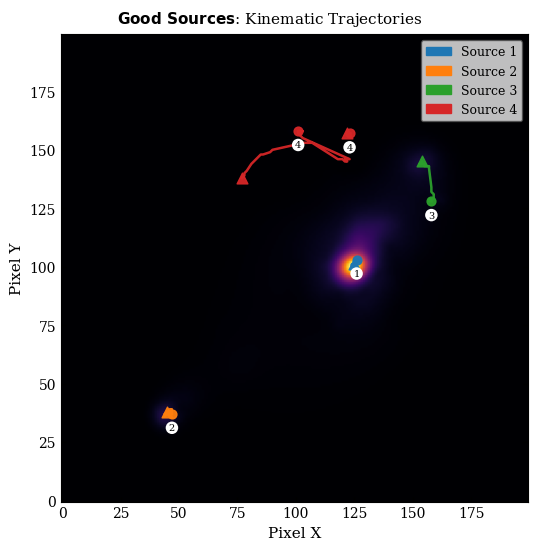

Saved trajectories.png
Saved kinematic_tracks.gif


In [9]:
Path(_RESULTS_DIR).mkdir(parents=True, exist_ok=True)
# ── Kinematic trajectories  (good sources only) ───────────────────────────
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family':   'serif',
    'font.size':      11,
    'axes.labelsize': 11,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
})

# chronological labels (recompute in case cell is run standalone)
def _first_ch(src):
    chs = [ch for t in tracks if t['id'] in src['track_ids'] for ch in t['masks']]
    return min(chs) if chs else 9999

_good_chrono  = sorted(good_sources, key=_first_ch)
_chrono_label = {src['id']: i + 1 for i, src in enumerate(_good_chrono)}
_good_ids     = {s['id'] for s in good_sources}
_good_tracks  = [t for t in tracks if t['source_id'] in _good_ids]

mean_img = cube[channel_list[len(channel_list)//2 - 2] :
                channel_list[len(channel_list)//2 + 3]].mean(axis=0)

# ── static trajectory plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(mean_img, cmap='inferno', origin='lower')
ax.set_xlabel('Pixel X', fontsize=11)
ax.set_ylabel('Pixel Y', fontsize=11)
ax.tick_params(which='both', direction='in', top=True, right=True)
fig.text(0.5, 0.98,
         r"$\mathbf{Good\ Sources}$: Kinematic Trajectories",
         ha='center', fontsize=11, fontfamily='serif')

for t in _good_tracks:
    sid   = t['source_id']
    color = src_colors[sid]
    clbl  = _chrono_label[sid]
    ys_t  = [p[1] for p in t['trajectory']]
    xs_t  = [p[2] for p in t['trajectory']]
    lw    = 1.8 if t['kinematic'] else 0.8
    alpha = 0.95 if t['kinematic'] else 0.4
    ax.plot(xs_t, ys_t, color=color, lw=lw, alpha=alpha)
    ax.scatter(xs_t[0],  ys_t[0],  s=40, color=color, zorder=5, marker='o', alpha=alpha)
    ax.scatter(xs_t[-1], ys_t[-1], s=60, color=color, zorder=5, marker='^', alpha=alpha)
    ax.text(xs_t[0], ys_t[0] - 4, str(clbl), color='black',
            fontsize=7, ha='center', va='top', fontfamily='serif',
            bbox=dict(boxstyle='circle,pad=0.18', fc='white', ec='none'), zorder=6)
    for ch_sp in t['split_at']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_sp:
                ax.plot(sx, sy, marker='*', ms=12, color=color, zorder=6)
                break
    for ch_mg, _ in t['merge_into']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_mg:
                ax.plot(sx, sy, marker='D', ms=8, color=color, zorder=6, alpha=0.7)
                break

# legend in chronological order
_patches = [mpatches.Patch(color=src_colors[s['id']],
                            label=f"Source {_chrono_label[s['id']]}")
            for s in _good_chrono]
ax.legend(handles=_patches, loc='upper right', fontsize=9,
          framealpha=0.75, edgecolor='0.3')

plt.tight_layout()
plt.savefig(f'{_RESULTS_DIR}/trajectories.png', dpi=130, bbox_inches='tight')
plt.savefig(f'{_RESULTS_DIR}/trajectories.pdf', dpi=130, bbox_inches='tight')
plt.show()
print('Saved trajectories.png')

# ── animated GIF — channel-by-channel ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5.5, 5.5))
ax2.set_xlabel('Pixel X', fontsize=11)
ax2.set_ylabel('Pixel Y', fontsize=11)
title2  = ax2.set_title('')
im_bg   = ax2.imshow(frames[0][1], cmap='inferno',
                     vmin=mean_img.min(), vmax=mean_img.max(), origin='lower')

line_artists, scatter_artists, contour_sets2 = [], [], []

def _update_traj(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_bg.set_data(img)
    title2.set_text(f'Channel {ch}')

    for a in line_artists + scatter_artists:
        a.remove()
    line_artists.clear(); scatter_artists.clear()
    for cs in contour_sets2:
        cs.remove()
    contour_sets2.clear()

    for mask in footprint_masks:
        sid = mask_to_source.get(id(mask), -1)
        if sid not in _good_ids:
            continue
        color = src_colors.get(sid, (1.0, 1.0, 1.0, 1.0))
        cs = ax2.contour(mask.astype(float), [0.5], colors=[color], linewidths=1.2)
        contour_sets2.append(cs)

    for t in _good_tracks:
        sid   = t['source_id']
        color = src_colors[sid]
        past  = [(py, px) for tc, py, px in t['trajectory'] if tc <= ch]
        if not past:
            continue
        lw    = 2.0 if t['kinematic'] else 0.8
        alpha = 0.95 if t['kinematic'] else 0.4
        ln, = ax2.plot([p[1] for p in past], [p[0] for p in past],
                       color=color, lw=lw, alpha=alpha)
        sc  = ax2.scatter(past[-1][1], past[-1][0],
                          s=50, color=color, zorder=5, alpha=alpha)
        line_artists.append(ln); scatter_artists.append(sc)

    return [im_bg, title2]

ani2 = animation.FuncAnimation(fig2, _update_traj, frames=len(frames), interval=700, blit=False)
ani2.save('kinematic_tracks.gif', writer='pillow', fps=1)
plt.close(fig2)
print('Saved kinematic_tracks.gif')

plt.rcParams.update(plt.rcParamsDefault)
